# Baseline CNN Training

This notebook prepares the data pipeline for training a baseline CNN model on the EuroSAT dataset.

**Objectives**

- Create train and validation splits
- Verify the custom PyTorch dataset
- Build DataLoaders
- Train a baseline CNN
- Evaluate model performance

## 1. Import Required Libraries

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from src.data.split import create_train_val_split
from src.data.dataset import EuroSATDataset
from src.data.transforms import (
    get_train_transforms,
    get_val_transforms,
)

In [3]:
train_paths, train_labels, val_paths, val_labels, class_to_idx = create_train_val_split()

print(f"Training Images   : {len(train_paths)}")
print(f"Validation Images : {len(val_paths)}")
print(f"Number of Classes : {len(class_to_idx)}")
print(class_to_idx)

Training Images   : 21600
Validation Images : 5400
Number of Classes : 10
{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


## 3. Create PyTorch Datasets

The custom `EuroSATDataset` class is used to load images and their corresponding labels.

Training images use data augmentation to improve model generalization, while validation images use only standard preprocessing to ensure fair evaluation.

In [4]:
train_dataset = EuroSATDataset(
    image_paths=train_paths,
    labels=train_labels,
    transform=get_train_transforms(),
)

val_dataset = EuroSATDataset(
    image_paths=val_paths,
    labels=val_labels,
    transform=get_val_transforms(),
)

print(f"Training Dataset   : {len(train_dataset)}")
print(f"Validation Dataset : {len(val_dataset)}")

Training Dataset   : 21600
Validation Dataset : 5400


### Observation

The dataset objects were created successfully.

- Training dataset contains **21,600** images.
- Validation dataset contains **5,400** images.

The datasets are now ready to be used with PyTorch DataLoaders.

## 4. Verify Dataset Samples

Before training the model, it is important to verify that the dataset returns correctly transformed images and labels.

In [5]:
image, label = train_dataset[0]

print("Image Shape :", image.shape)
print("Image Type  :", image.dtype)
print("Label       :", label)

Image Shape : torch.Size([3, 224, 224])
Image Type  : torch.float32
Label       : 0


### Expected Output

- Image shape: **(3, 64, 64)**
- Data type: **torch.float32**
- Label: Integer between **0** and **9**

## 5. Visualize a Sample Image

The image is unnormalized before visualization so that the original colors are displayed correctly.

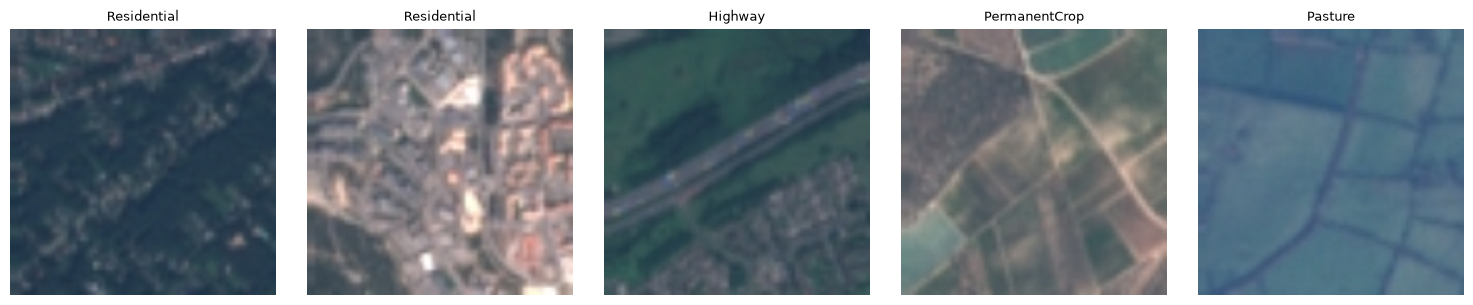

In [6]:
import random
import matplotlib.pyplot as plt
import torch

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

idx_to_class = {idx: name for name, idx in class_to_idx.items()}

plt.figure(figsize=(15, 3))

for i in range(5):
    idx = random.randint(0, len(val_dataset) - 1)

    image, label = val_dataset[idx]

    image = image * std + mean
    image = image.permute(1, 2, 0).numpy()

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title(idx_to_class[label], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Observation

The sample image is displayed correctly after reversing the normalization process. This confirms that:

- Images are loaded successfully.
- Data transformations are applied correctly.
- Labels are aligned with the corresponding images.

The data pipeline is now verified and ready for building PyTorch DataLoaders.

## Conclusion

The data pipeline has been verified successfully.

Completed tasks:

- Created a stratified train-validation split.
- Built a custom PyTorch dataset.
- Verified image loading and preprocessing.
- Confirmed that labels are mapped correctly.

The dataset is now ready for creating PyTorch DataLoaders and training the baseline CNN model.

# 6. Create PyTorch DataLoaders

PyTorch DataLoaders are responsible for loading data in mini-batches during training and validation.

Using DataLoaders improves training efficiency by batching samples, shuffling the training data, and enabling parallel data loading.

In [7]:
from torch.utils.data import DataLoader

from src.config import BATCH_SIZE

In [8]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [9]:
print(f"Training Batches   : {len(train_loader)}")
print(f"Validation Batches : {len(val_loader)}")
print(f"Batch Size         : {BATCH_SIZE}")

Training Batches   : 675
Validation Batches : 169
Batch Size         : 32


In [10]:
images, labels = next(iter(train_loader))

print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

Images Shape : torch.Size([32, 3, 224, 224])
Labels Shape : torch.Size([32])


### Observation

The DataLoaders were created successfully.

- Training data is shuffled before every epoch.
- Validation data remains in a fixed order.
- Images are loaded in mini-batches, making the pipeline ready for model training.

The data pipeline is now fully complete.

# 7. Build Baseline CNN Model

A simple Convolutional Neural Network (CNN) is implemented as the baseline model for land-use classification.

This model serves as a reference point for evaluating the improvements achieved using transfer learning in later stages of the project.

In [11]:
from src.models.baseline_cnn import BaselineCNN

In [12]:
model = BaselineCNN()

print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


## 8. Verify Forward Pass

Before training the model, a forward pass is performed using one mini-batch from the DataLoader.

This ensures that the model architecture is compatible with the input data and produces the expected output shape.

In [13]:
images, labels = next(iter(train_loader))

outputs = model(images)

print("Input Shape :", images.shape)
print("Output Shape:", outputs.shape)

Input Shape : torch.Size([32, 3, 224, 224])
Output Shape: torch.Size([32, 10])


### Observation

The model successfully processed one batch of images.

The output tensor has shape `(32, 10)`, indicating that the model produces one prediction vector for each image across the 10 land-use classes.

This confirms that the model architecture is ready for training.

## 8. Verify Forward Pass

Before training the model, a forward pass is performed using one mini-batch from the training DataLoader.

This confirms that the model accepts the input images and produces predictions with the correct output dimensions.

In [14]:
images, labels = next(iter(train_loader))

outputs = model(images)

print(f"Input Shape  : {images.shape}")
print(f"Output Shape : {outputs.shape}")

Input Shape  : torch.Size([32, 3, 224, 224])
Output Shape : torch.Size([32, 10])


## 9. Count Trainable Parameters

The total number of trainable parameters provides an estimate of the model's complexity and computational requirements.

In [15]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")

Total Parameters      : 128,842
Trainable Parameters  : 128,842


### Observation

The baseline CNN has a relatively small number of trainable parameters, making it computationally efficient and suitable as a reference model before applying transfer learning.

In [16]:
model = BaselineCNN()

print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [17]:
from src.models.baseline_cnn import BaselineCNN

In [18]:
total_params = sum(p.numel() for p in model.parameters())

print(total_params)

128842


In [19]:
print(model.classifier)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=128, out_features=256, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=256, out_features=10, bias=True)
)


In [20]:
import inspect
from src.models.baseline_cnn import BaselineCNN

print(inspect.getfile(BaselineCNN))

C:\Users\Akshit\satellite-landuse-change-detector\src\models\baseline_cnn.py


In [21]:
from pathlib import Path

print(Path("src/models/baseline_cnn.py").resolve())

C:\Users\Akshit\satellite-landuse-change-detector\notebooks\src\models\baseline_cnn.py


In [22]:
import inspect

from src.models.baseline_cnn import BaselineCNN

print(inspect.getsource(BaselineCNN))

class BaselineCNN(nn.Module):
    """
    Simple CNN architecture for image classification.
    """

    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # NEW
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x



In [23]:
from src.models.baseline_cnn import BaselineCNN

model = BaselineCNN()

In [24]:
print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [25]:
total_params = sum(p.numel() for p in model.parameters())

print(total_params)

128842


In [26]:
print(model.classifier)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=128, out_features=256, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=256, out_features=10, bias=True)
)


In [27]:
import src.models.baseline_cnn as cnn

print(cnn.__file__)
print("-" * 80)

with open(cnn.__file__, "r", encoding="utf-8") as f:
    print(f.read())

C:\Users\Akshit\satellite-landuse-change-detector\src\models\baseline_cnn.py
--------------------------------------------------------------------------------
"""
baseline_cnn.py
---------------
Baseline CNN model for EuroSAT land-use classification.
"""

import torch.nn as nn


class BaselineCNN(nn.Module):
    """
    Simple CNN architecture for image classification.
    """

    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # NEW
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
          

In [28]:
id(BaselineCNN)

2528358192352

In [29]:
print(BaselineCNN.__module__)

src.models.baseline_cnn


### Observation

The optimized baseline CNN contains **128,842 trainable parameters**, making it lightweight and computationally efficient.

The use of `AdaptiveAvgPool2d` significantly reduces the number of parameters by replacing a large fully connected layer while preserving the extracted feature information.

This architecture serves as a strong baseline for comparison with transfer learning models in later stages of the project.

# 10. Configure Training

This section defines the loss function, optimizer, and training configuration required to train the baseline CNN model.

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim

from src.training.trainer import fit
from src.config import DEVICE

In [31]:
model = BaselineCNN().to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
)

print(f"Device : {DEVICE}")
print(f"Loss   : {criterion.__class__.__name__}")
print(f"Optimizer : {optimizer.__class__.__name__}")

Device : cpu
Loss   : CrossEntropyLoss
Optimizer : Adam


In [32]:
EPOCHS = 5

history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    epochs=EPOCHS,
)


Epoch [1/5]


Train Loss: 1.5558 | Train Acc: 41.12%
Train Loss: 1.5558 | Train Acc: 41.12%
Val Loss: 1.0826 | Val Acc: 0.62%

Epoch [2/5]


Train Loss: 1.1384 | Train Acc: 58.20%
Train Loss: 1.1384 | Train Acc: 58.20%
Val Loss: 0.9228 | Val Acc: 0.65%

Epoch [3/5]


Train Loss: 0.9943 | Train Acc: 63.91%
Train Loss: 0.9943 | Train Acc: 63.91%
Val Loss: 0.7931 | Val Acc: 0.71%

Epoch [4/5]


Train Loss: 0.8898 | Train Acc: 67.63%
Train Loss: 0.8898 | Train Acc: 67.63%
Val Loss: 0.8378 | Val Acc: 0.69%

Epoch [5/5]


Train Loss: 0.8382 | Train Acc: 69.92%
Train Loss: 0.8382 | Train Acc: 69.92%
Val Loss: 0.6456 | Val Acc: 0.77%
